<a href="https://colab.research.google.com/github/ved-ingole/Convolutional-Neural-Network-CNN-using-Keras/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network (CNN) using Keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display dataset shape
print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


In [ ]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# Reshape images for CNN input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training Image Shape :", x_train.shape)
print("Testing Image Shape  :", x_test.shape)

Training Image Shape : (60000, 28, 28, 1)
Testing Image Shape  : (10000, 28, 28, 1)


In [ ]:
# Convert labels to one-hot vectors
num_classes = 10

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("Training Label Shape :", y_train.shape)
print("Testing Label Shape  :", y_test.shape)

Training Label Shape : (60000, 10)
Testing Label Shape  : (10000, 10)


In [ ]:
model = keras.Sequential([

    # Input Layer
    keras.Input(shape=(28, 28, 1)),

    # Convolution Block 1
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # Convolution Block 2
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # Flatten Feature Maps
    layers.Flatten(),

    # Dropout Layer
    layers.Dropout(0.5),

    # Fully Connected Layer
    layers.Dense(128, activation="relu"),

    # Output Layer
    layers.Dense(num_classes, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - accuracy: 0.9918 - loss: 0.0241 - val_accuracy: 0.9930 - val_loss: 0.0265
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 98ms/step - accuracy: 0.9930 - loss: 0.0212 - val_accuracy: 0.9935 - val_loss: 0.0255
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9945 - val_loss: 0.0240
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.9937 - loss: 0.0188 - val_accuracy: 0.9935 - val_loss: 0.0262
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.9938 - loss: 0.0174 - val_accuracy: 0.9935 - val_loss: 0.0260
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 108ms/step - accuracy: 0.9944 - loss: 0.0163 - val_accuracy: 0.9940 - val_loss: 0.0274
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 100ms/step - accuracy: 0.9945 - loss: 0.0161 - val_accuracy: 0.9935 - val_loss: 0.0296
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9950 - loss: 0.014

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 99.37%
Test Loss     : 0.0235


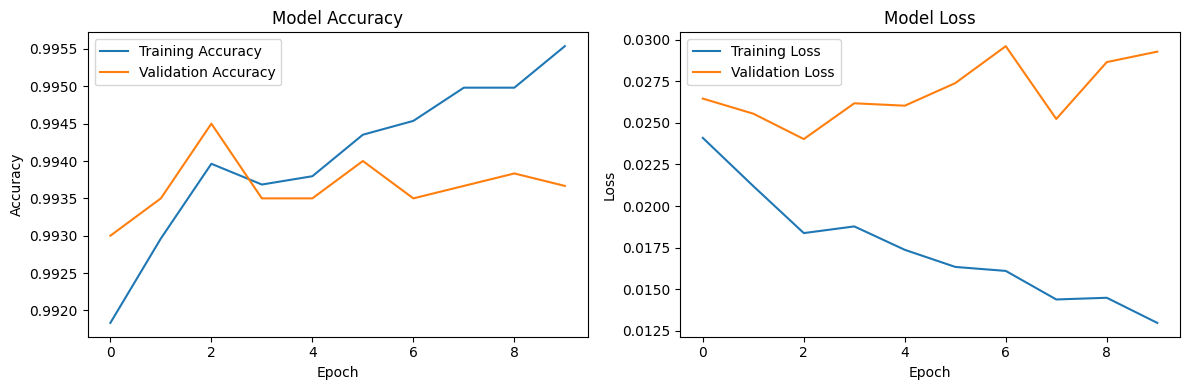

In [ ]:
plt.figure(figsize=(12,4))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_history.png")
plt.show()

In [ ]:
model.save("mnist_cnn_model.keras")

print("Model saved successfully as mnist_cnn_model.keras")

Model saved successfully as mnist_cnn_model.keras
